In [1]:
# Suraksha Analytics - Crime Data Analysis Notebook
# This notebook demonstrates the key functionality from Data.py in an interactive format

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set seaborn style for better plots
sns.set(style="whitegrid", palette="deep")

print("📊 Suraksha Analytics - Crime Data Analysis")
print("=" * 50)
print("This notebook provides interactive crime data analysis capabilities")
print("Run cells sequentially to analyze crime data across Indian states and districts")

📊 Suraksha Analytics - Crime Data Analysis
This notebook provides interactive crime data analysis capabilities
Run cells sequentially to analyze crime data across Indian states and districts


In [ ]:
# Load and clean datasets
def clean_dataset(df):
    """Apply standard cleaning operations to a dataframe"""
    print(f"Cleaning dataframe... Original shape: {df.shape}")
    
    # Standardize key text columns
    key_cols = ['State Name', 'District Name']
    for col in key_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.lower().str.strip()
    
    # Clean and standardize 'Year' column
    if 'Year' in df.columns:
        df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
        df = df.dropna(subset=['Year'])
        df['Year'] = df['Year'].astype(int)
    
    # Clean crime/data columns
    metadata_cols = ['ID', 'Year', 'State Name', 'State Code', 'District Name', 'District Code', 'Registration Circles']
    crime_cols = [col for col in df.columns if col not in metadata_cols]
    
    if crime_cols:
        for col in crime_cols:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        df[crime_cols] = df[crime_cols].fillna(0)
    
    # Drop duplicates
    id_subset = ['State Name', 'District Name', 'Year']
    existing_id_subset = [c for c in id_subset if c in df.columns]
    if existing_id_subset:
        df = df.drop_duplicates(subset=existing_id_subset, keep='first')
    
    print(f"Cleaning complete. New shape: {df.shape}")
    return df

# Load datasets
try:
    datasets = {
        'ipc': pd.read_csv('Dataset/districtwise_ipc_crimes_readable.csv'),
        'crime_against_women': pd.read_csv('Dataset/districtwise_crime_against_women_readable.csv'),
        'cyber_crimes': pd.read_csv('Dataset/districtwise_cyber_crimes_readable.csv'),
        'juveniles': pd.read_csv('Dataset/crime-by-juveniles-expanded.csv'),
        'missing_persons': pd.read_csv('Dataset/districtwise-missing-persons-merged.csv')
    }
    
    # Clean all datasets
    for name in datasets.keys():
        datasets[name] = clean_dataset(datasets[name])
    
    print(f"\n✅ Successfully loaded {len(datasets)} datasets:")
    for name, df in datasets.items():
        print(f"   - {name}: {df.shape[0]} records, {df.shape[1]} columns")
        
except Exception as e:
    print(f"❌ Error loading datasets: {e}")
    print("Make sure all CSV files are in the 'Dataset' folder")

Cleaning dataframe... Original shape: (5322, 124)
Cleaning complete. New shape: (4341, 124)
Cleaning dataframe... Original shape: (5322, 49)
Cleaning complete. New shape: (4336, 49)
Cleaning dataframe... Original shape: (5322, 48)
Cleaning complete. New shape: (4365, 48)
Cleaning dataframe... Original shape: (5322, 124)
Cleaning complete. New shape: (4341, 124)
Cleaning dataframe... Original shape: (5322, 49)
Cleaning complete. New shape: (4336, 49)
Cleaning dataframe... Original shape: (5322, 48)
Cleaning complete. New shape: (4365, 48)
Cleaning dataframe... Original shape: (5322, 124)
Cleaning complete. New shape: (4341, 124)
Cleaning dataframe... Original shape: (3478, 25)
Cleaning complete. New shape: (2865, 25)
Cleaning dataframe... Original shape: (1841, 21)
Cleaning complete. New shape: (1485, 21)

✅ Successfully loaded 6 datasets:
   - ipc: 4341 records, 124 columns
   - crime_against_women: 4336 records, 49 columns
   - cyber_crimes: 4365 records, 48 columns
   - juveniles: 43

In [3]:
# Explore available states and districts
if 'datasets' in locals() and datasets:
    # Use IPC dataset as master reference
    master_df = datasets['ipc']
    
    print("📍 Available States:")
    states = sorted(master_df['State Name'].unique())
    for i, state in enumerate(states[:10], 1):  # Show first 10 states
        print(f"   {i:2d}. {state.title()}")
    
    if len(states) > 10:
        print(f"   ... and {len(states) - 10} more states")
    
    print(f"\n📈 Dataset Overview:")
    print(f"   Total States: {len(states)}")
    print(f"   Total Districts: {master_df['District Name'].nunique()}")
    print(f"   Year Range: {master_df['Year'].min()} - {master_df['Year'].max()}")
    
    # Show sample data structure
    print(f"\n📋 Sample Data Structure (IPC Crimes):")
    crime_columns = [col for col in master_df.columns if col not in 
                     ['ID', 'Year', 'State Name', 'State Code', 'District Name', 'District Code', 'Registration Circles']]
    print(f"   Crime Types Available: {len(crime_columns)}")
    for i, crime in enumerate(crime_columns[:5], 1):
        print(f"   {i}. {crime}")
    if len(crime_columns) > 5:
        print(f"   ... and {len(crime_columns) - 5} more crime types")
else:
    print("❌ Datasets not loaded. Please run the previous cell first.")

📍 Available States:
    1. Andaman And Nicobar Islands
    2. Andhra Pradesh
    3. Arunachal Pradesh
    4. Assam
    5. Bihar
    6. Chandigarh
    7. Chhattisgarh
    8. Delhi
    9. Goa
   10. Gujarat
   ... and 26 more states

📈 Dataset Overview:
   Total States: 36
   Total Districts: 749
   Year Range: 2017 - 2022

📋 Sample Data Structure (IPC Crimes):
   Crime Types Available: 117
   1. Murder
   2. Culpable Homicide not Amounting to Murder
   3. Hit and Run
   4. Accidents Other than Hit and Run
   5. Deaths due to Negligence related to Rail Accidents
   ... and 112 more crime types


In [4]:
# Interactive Analysis - Set your parameters here
# Modify these variables to analyze different states/districts/crimes

# Configuration
STATE_NAME = "uttar pradesh"  # Change this to your state of interest
DISTRICT_NAME = "agra"        # Change this to your district, or "all" for entire state
DATASET_NAME = "ipc"          # Options: 'ipc', 'crime_against_women', 'cyber_crimes', 'juveniles', etc.
CRIME_TYPE = "MURDER"         # Change this to the crime type you want to analyze

print(f"🎯 Analysis Configuration:")
print(f"   State: {STATE_NAME.title()}")
print(f"   District: {DISTRICT_NAME.title() if DISTRICT_NAME != 'all' else 'All Districts'}")
print(f"   Dataset: {DATASET_NAME}")
print(f"   Crime Type: {CRIME_TYPE}")
print("\n" + "="*50)

🎯 Analysis Configuration:
   State: Uttar Pradesh
   District: Agra
   Dataset: ipc
   Crime Type: MURDER



In [5]:
# Data Analysis and Visualization Functions

def plot_crime_trend(data, state, district, crime):
    """Plot crime trend over years"""
    if data.empty:
        print("No data to plot.")
        return
    
    if crime not in data.columns:
        print(f"Crime '{crime}' not found in dataset.")
        return
    
    yearly = data.groupby("Year")[crime].sum().reset_index()
    
    if yearly.empty or yearly[crime].sum() == 0:
        print(f"No reported cases of '{crime}' found.")
        return
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=yearly, x="Year", y=crime, marker="o")
    
    title = f"{crime} Trend in {district.title()}, {state.title()}"
    if district == 'all':
        title = f"Total {crime} Trend in {state.title()}"
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Number of Cases", fontsize=12)
    plt.xticks(yearly['Year'].astype(int))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    total_cases = yearly[crime].sum()
    avg_cases = yearly[crime].mean()
    peak_year = yearly.loc[yearly[crime].idxmax(), 'Year']
    peak_cases = yearly[crime].max()
    
    print(f"\n📊 Summary Statistics:")
    print(f"   Total Cases: {total_cases:,}")
    print(f"   Average per Year: {avg_cases:.1f}")
    print(f"   Peak Year: {peak_year} ({peak_cases:,} cases)")

def show_district_comparison(dataset, state, crime, top_n=10):
    """Show top N districts for a specific crime in bar chart"""
    state_data = dataset[dataset['State Name'] == state]
    
    if state_data.empty:
        print(f"No data found for state: {state}")
        return
    
    if crime not in state_data.columns:
        print(f"Crime '{crime}' not found in dataset.")
        return
    
    district_totals = state_data.groupby("District Name")[crime].sum().reset_index()
    district_totals = district_totals[district_totals[crime] > 0]
    district_totals = district_totals.sort_values(by=crime, ascending=False).head(top_n)
    
    if district_totals.empty:
        print(f"No data found for '{crime}' in {state}")
        return
    
    plt.figure(figsize=(12, 8))
    sns.barplot(data=district_totals, y="District Name", x=crime, palette="viridis")
    plt.title(f"Top {top_n} Districts for '{crime}' in {state.title()}", fontsize=14, fontweight='bold')
    plt.xlabel("Total Number of Cases", fontsize=12)
    plt.ylabel("District", fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return district_totals

✅ Found 6 records for Agra, Uttar Pradesh
   Year range: 2017 - 2022
   Analyzing crime type: Murder


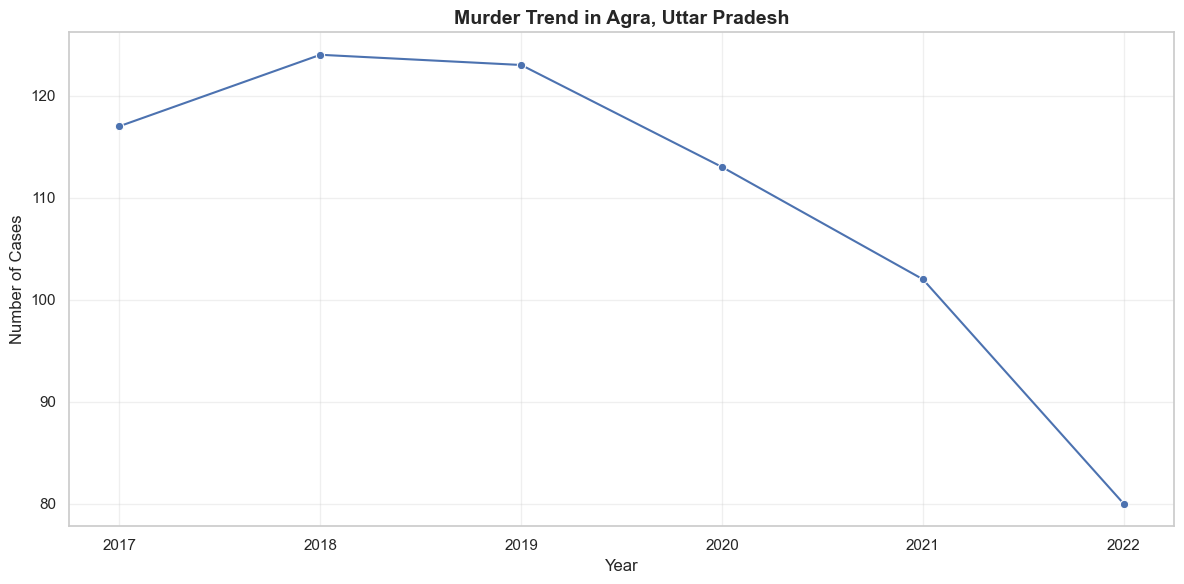


📊 Summary Statistics:
   Total Cases: 659.0
   Average per Year: 109.8
   Peak Year: 2018 (124.0 cases)


In [6]:
# Execute Analysis Based on Configuration

if 'datasets' in locals() and datasets and DATASET_NAME in datasets:
    # Get the selected dataset
    selected_dataset = datasets[DATASET_NAME]
    
    # Filter data based on configuration
    if DISTRICT_NAME.lower() == 'all':
        # Analyze entire state
        filtered_data = selected_dataset[selected_dataset['State Name'] == STATE_NAME.lower()]
        location_desc = f"All Districts in {STATE_NAME.title()}"
    else:
        # Analyze specific district
        filtered_data = selected_dataset[
            (selected_dataset['State Name'] == STATE_NAME.lower()) & 
            (selected_dataset['District Name'] == DISTRICT_NAME.lower())
        ]
        location_desc = f"{DISTRICT_NAME.title()}, {STATE_NAME.title()}"
    
    if filtered_data.empty:
        print(f"❌ No data found for {location_desc} in {DATASET_NAME} dataset")
        print("   Please check your STATE_NAME and DISTRICT_NAME configuration")
    else:
        print(f"✅ Found {len(filtered_data)} records for {location_desc}")
        print(f"   Year range: {filtered_data['Year'].min()} - {filtered_data['Year'].max()}")
        
        # Check if crime type exists
        crime_columns = [col for col in selected_dataset.columns if col not in 
                        ['ID', 'Year', 'State Name', 'State Code', 'District Name', 'District Code', 'Registration Circles']]
        
        if CRIME_TYPE.upper() in [c.upper() for c in crime_columns]:
            # Find exact match (case insensitive)
            actual_crime = next(c for c in crime_columns if c.upper() == CRIME_TYPE.upper())
            print(f"   Analyzing crime type: {actual_crime}")
            
            # Plot the trend
            plot_crime_trend(filtered_data, STATE_NAME, DISTRICT_NAME, actual_crime)
            
        else:
            print(f"❌ Crime type '{CRIME_TYPE}' not found in {DATASET_NAME} dataset")
            print(f"   Available crime types: {crime_columns[:5]}...")
else:
    print("❌ Please run the dataset loading cell first")

🏆 Top Districts Analysis for 'Murder' in Uttar Pradesh


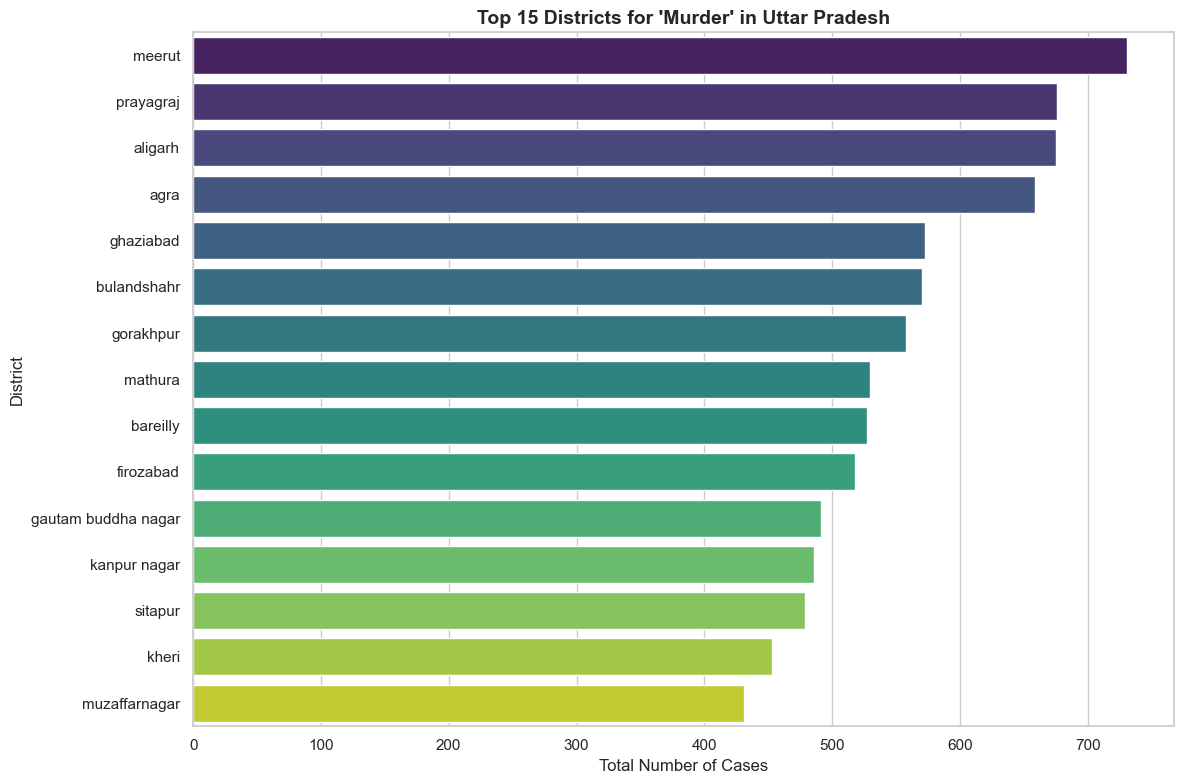


📋 Top 5 Districts for Murder:
   1. Meerut: 731.0 cases
   2. Prayagraj: 676.0 cases
   3. Aligarh: 675.0 cases
   4. Agra: 659.0 cases
   5. Ghaziabad: 573.0 cases


In [7]:
# District Comparison Analysis
# This cell shows the top districts for the selected crime type in the selected state

if 'datasets' in locals() and datasets and DATASET_NAME in datasets:
    selected_dataset = datasets[DATASET_NAME]
    
    # Find the crime type (case insensitive)
    crime_columns = [col for col in selected_dataset.columns if col not in 
                    ['ID', 'Year', 'State Name', 'State Code', 'District Name', 'District Code', 'Registration Circles']]
    
    matching_crimes = [c for c in crime_columns if c.upper() == CRIME_TYPE.upper()]
    
    if matching_crimes:
        actual_crime = matching_crimes[0]
        print(f"🏆 Top Districts Analysis for '{actual_crime}' in {STATE_NAME.title()}")
        print("="*60)
        
        top_districts = show_district_comparison(selected_dataset, STATE_NAME.lower(), actual_crime, top_n=15)
        
        if top_districts is not None and not top_districts.empty:
            print(f"\n📋 Top 5 Districts for {actual_crime}:")
            for i, (_, row) in enumerate(top_districts.head().iterrows(), 1):
                print(f"   {i}. {row['District Name'].title()}: {row[actual_crime]:,} cases")
    else:
        print(f"❌ Crime type '{CRIME_TYPE}' not found. Available crimes:")
        for crime in crime_columns[:10]:
            print(f"   - {crime}")
else:
    print("❌ Please run the dataset loading cell first")

📊 Multi-Crime Comparison for Agra, Uttar Pradesh


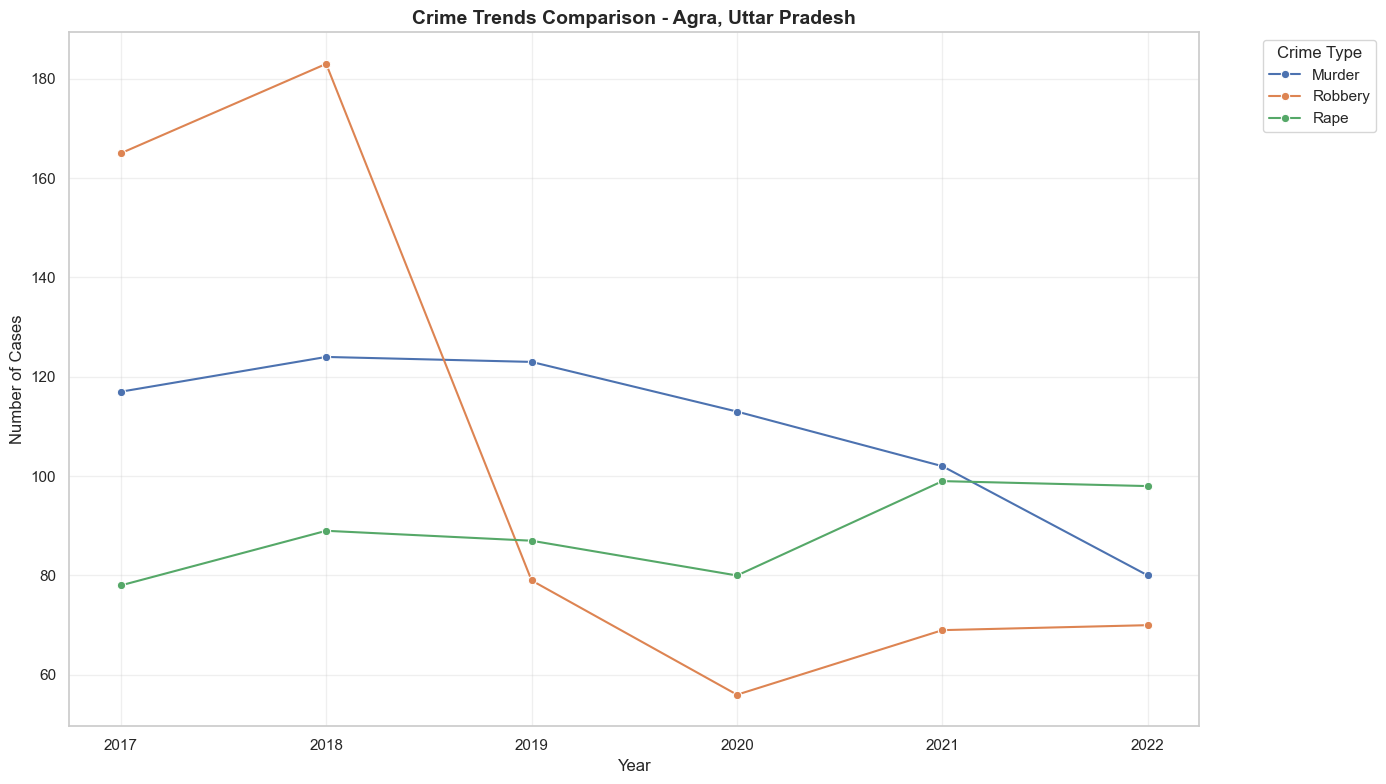


📈 Total Cases Summary:
   Murder: 659.0 cases
   Robbery: 622.0 cases
   Rape: 531.0 cases


In [8]:
# Multiple Crime Types Comparison
# Compare different crime types in the same location

# Define crimes to compare (modify this list as needed)
CRIMES_TO_COMPARE = ["MURDER", "THEFT", "ROBBERY", "BURGLARY", "RAPE"]

if 'datasets' in locals() and datasets and DATASET_NAME in datasets:
    selected_dataset = datasets[DATASET_NAME]
    
    # Filter data for location
    if DISTRICT_NAME.lower() == 'all':
        filtered_data = selected_dataset[selected_dataset['State Name'] == STATE_NAME.lower()]
        location_desc = f"All Districts in {STATE_NAME.title()}"
    else:
        filtered_data = selected_dataset[
            (selected_dataset['State Name'] == STATE_NAME.lower()) & 
            (selected_dataset['District Name'] == DISTRICT_NAME.lower())
        ]
        location_desc = f"{DISTRICT_NAME.title()}, {STATE_NAME.title()}"
    
    if not filtered_data.empty:
        # Find available crimes from our comparison list
        available_columns = selected_dataset.columns.tolist()
        available_crimes = []
        
        for crime in CRIMES_TO_COMPARE:
            matching = [col for col in available_columns if col.upper() == crime.upper()]
            if matching:
                available_crimes.append(matching[0])
        
        if available_crimes:
            print(f"📊 Multi-Crime Comparison for {location_desc}")
            print("="*60)
            
            # Create yearly aggregation for each crime
            yearly_data = filtered_data.groupby("Year")[available_crimes].sum().reset_index()
            
            if not yearly_data.empty:
                # Create the comparison plot
                plt.figure(figsize=(14, 8))
                
                for crime in available_crimes:
                    if yearly_data[crime].sum() > 0:  # Only plot crimes with data
                        sns.lineplot(data=yearly_data, x="Year", y=crime, marker="o", label=crime)
                
                plt.title(f"Crime Trends Comparison - {location_desc}", fontsize=14, fontweight='bold')
                plt.xlabel("Year", fontsize=12)
                plt.ylabel("Number of Cases", fontsize=12)
                plt.legend(title="Crime Type", bbox_to_anchor=(1.05, 1), loc='upper left')
                plt.xticks(yearly_data['Year'].astype(int))
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.show()
                
                # Show summary table
                print(f"\n📈 Total Cases Summary:")
                totals = yearly_data[available_crimes].sum().sort_values(ascending=False)
                for crime, total in totals.items():
                    if total > 0:
                        print(f"   {crime}: {total:,} cases")
            else:
                print("No yearly data available for comparison")
        else:
            print(f"❌ None of the specified crimes found in {DATASET_NAME} dataset")
            print("Available crime types:")
            crime_columns = [col for col in selected_dataset.columns if col not in 
                           ['ID', 'Year', 'State Name', 'State Code', 'District Name', 'District Code', 'Registration Circles']]
            for crime in crime_columns[:10]:
                print(f"   - {crime}")
    else:
        print(f"❌ No data found for {location_desc}")
else:
    print("❌ Please run the dataset loading cell first")

In [9]:
# Dataset Summary and Quick Stats

if 'datasets' in locals() and datasets:
    print("📊 SURAKSHA ANALYTICS - COMPLETE DATASET SUMMARY")
    print("="*70)
    
    for dataset_name, df in datasets.items():
        print(f"\n🗂️  {dataset_name.upper().replace('_', ' ')} DATASET")
        print("-" * 50)
        
        # Basic info
        print(f"   Records: {len(df):,}")
        print(f"   Years: {df['Year'].min()} - {df['Year'].max()}")
        print(f"   States: {df['State Name'].nunique()}")
        print(f"   Districts: {df['District Name'].nunique()}")
        
        # Crime types
        crime_columns = [col for col in df.columns if col not in 
                        ['ID', 'Year', 'State Name', 'State Code', 'District Name', 'District Code', 'Registration Circles']]
        print(f"   Crime Types: {len(crime_columns)}")
        
        # Top crimes by total cases
        if crime_columns:
            crime_totals = df[crime_columns].sum().sort_values(ascending=False).head(3)
            print("   Top 3 Crimes by Total Cases:")
            for crime, total in crime_totals.items():
                print(f"      • {crime}: {total:,}")
    
    print(f"\n🎯 QUICK ANALYSIS TIPS:")
    print("   1. Modify the configuration cell to change analysis parameters")
    print("   2. Available datasets: " + ", ".join(datasets.keys()))
    print("   3. Use 'all' as DISTRICT_NAME to analyze entire state")
    print("   4. Check available crime types in the exploration cell")
    
else:
    print("❌ No datasets loaded. Please run the data loading cell first.")

📊 SURAKSHA ANALYTICS - COMPLETE DATASET SUMMARY

🗂️  IPC DATASET
--------------------------------------------------
   Records: 4,341
   Years: 2017 - 2022
   States: 36
   Districts: 749
   Crime Types: 117
   Top 3 Crimes by Total Cases:
      • Other IPC Crimes: 2,224,495.0
      • Other Thefts: 1,539,530.0
      • Voluntarily Causing Simple Hurt: 1,453,572.0

🗂️  CRIME AGAINST WOMEN DATASET
--------------------------------------------------
   Records: 4,336
   Years: 2017 - 2022
   States: 36
   Districts: 751
   Crime Types: 42
   Top 3 Crimes by Total Cases:
      • Cruelty by Husband or His Relatives: 596,193.0
      • Assault on Women (Above 18): 422,472.0
      • Kidnapping and Abduction: 163,079.0

🗂️  CYBER CRIMES DATASET
--------------------------------------------------
   Records: 4,365
   Years: 2017 - 2022
   States: 36
   Districts: 751
   Crime Types: 41
   Top 3 Crimes by Total Cases:
      • Total Offences under IPC: 99,637.0
      • Cheating by Personation using C